# 1 - Acquire Amsterdam open panoramas and build the H5 store

This notebook **acquires** the street-level imagery for the study and assembles it into the HDF5 data
store that the rest of the pipeline uses. The heavy, restartable network work lives in the standalone,
resumable script `panorama_acquisition.py`; this notebook documents how to run it and then
**sanity-checks** the resulting H5 store.

**Imagery source:** City of Amsterdam Open Panorama ("Kernregistratie panoramabeelden"),
published by Gemeente Amsterdam, licensed **CC-BY 4.0**, with faces and number plates blurred at
source. See `DATA_PROVENANCE.md`.

**What the acquisition script does** (see its module docstring + the constants block at the top of
`panorama_acquisition.py` for detail; the named knobs below are those constants):

1. **Builds a work list** of which panoramas to fetch. For each gemeente in `MUNICIPALITY_CODES` it
   queries the REST API tile by tile for the *most recent* panorama per location (`newest_in_range`),
   keeping only points that fall in buurten with a CBS SES-WOA score (the model target). All
   municipalities are then **pooled and thinned together** density-proportionally — a fixed *share* of
   the panoramas is kept within each `STRATUM_M` grid cell, so the sample density tracks local road
   density *uniformly across the whole region* — down to roughly `TARGET_N` points in total. A
   `MIN_SPACING_M` anti-clump floor drops near-duplicates first, and an **additive** `MIN_PER_BUURT`
   floor afterwards tops up any sparsely-covered buurt so every scored buurt has enough panoramas for
   a stable median embedding.
2. **Downloads** each equirectangular panorama and reprojects it into **four 90 deg FOV rectilinear
   crops** facing N/E/S/W, so CLIP receives in-distribution rectangular images (raw equirectangular
   panoramas are never embedded).
3. **Writes the H5 structure** the downstream notebooks expect, so notebooks 2+ run unchanged.

**If a panorama isn't available** this is handled at two stages. (i) At *work-list* time, if a whole
mission year's imagery has been withdrawn from the server — its year is listed in
`UNAVAILABLE_MISSION_YEARS`, where it is still advertised by the API but every image 404s — the tile
falls back to the newest mission that *does* still have imagery, so the dead records never enter the
work list. (ii) At *download* time, any individual image that still 404s is skipped (logged, not
retried, and left out of the manifest), so it simply never reaches the H5; the `MIN_PER_BUURT` floor
leaves headroom for the occasional loss. The result is three reconciled "views" of the sample —
work list → manifest → H5 — checked in the verification cells below.

The downloader is fully resumable/idempotent: it is safe to Ctrl-C and rerun until complete.

## Run the acquisition

Run from the `notebooks/` directory (it is safe to interrupt and rerun at any point):

```bash
# small development bounding box (lon/lat order) - a few dozen points:
python panorama_acquisition.py --bbox 4.890 52.368 4.900 52.374

# whole study region — every gemeente in MUNICIPALITY_CODES (accumulates across runs):
python panorama_acquisition.py
```

Tuning knobs (request delay, image variant/size, FOV, headings, the `TARGET_N` density-proportional
thinning budget, the `MIN_PER_BUURT` floor, the `UNAVAILABLE_MISSION_YEARS` withdrawn-imagery
fallback, etc.) are the constants at the top of `panorama_acquisition.py`.

In [1]:
import io
import h5py
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from directory_filepaths import *  # includes h5_filename

### Sanity-check the H5 store
Provenance is recorded in the root attributes; the datasets are the image schema used throughout the pipeline
(`point_id`, `latitude`, `longitude`, `date`, `image_paths`, `images_present`, `images_jpeg`) plus
Amsterdam-native `pano_id` and `mission_year`.

In [2]:
with h5py.File(h5_filename, "r") as f:
    print("Provenance (root attributes):")
    for k, v in f.attrs.items():
        print(f"    {k}: {v}")

    print(f"\nH5 data store: {h5_filename}")
    print(f"{'Dataset':<18}{'Shape':<14}{'Dtype'}")
    print("-" * 50)
    for key in sorted(f.keys()):
        ds = f[key]
        print(f"{key:<18}{str(ds.shape):<14}{ds.dtype}")

    N = f["point_id"].shape[0]
    n_images = int(np.count_nonzero(f["images_present"][:]))
    print(f"\nTotal points: {N}")
    print(f"Images present: {n_images} / {N * 4}")

Provenance (root attributes):
    attribution: Contains data from Gemeente Amsterdam, licensed under CC-BY 4.0
    fov_deg: 90
    headings: [  0  90 180 270]
    image_source: City of Amsterdam Open Panorama (Kernregistratie panoramabeelden)
    img_size: 640
    licence: CC-BY 4.0
    privacy: faces and number plates blurred at source

H5 data store: ../data/processed/street_data.h5
Dataset           Shape         Dtype
--------------------------------------------------
date              (50048,)      |S10
embeddings_clip   (50048, 4, 512)float32
image_paths       (50048, 4)    |S512
images_jpeg       (50048, 4)    object
images_present    (50048, 4)    bool
latitude          (50048,)      float64
longitude         (50048,)      float64
mission_year      (50048,)      int32
pano_id           (50048,)      |S64
point_id          (50048,)      int32

Total points: 50048
Images present: 200192 / 200192


In [3]:
with h5py.File(h5_filename, "r") as f:
    print("Point 0 metadata:")
    for x in ["point_id", "pano_id", "latitude", "longitude", "date", "mission_year"]:
        val = f[x][0]
        print(f"    {x}: {val.decode() if isinstance(val, bytes) else val}")

Point 0 metadata:
    point_id: 0
    pano_id: TMX7316010203-002266_pano_0000_000704
    latitude: 52.3383313335052
    longitude: 5.1357867600834
    date: 2021-08
    mission_year: 2021


### Display the four cardinal views for one point
Slot order is N, E, S, W (headings 0/90/180/270).

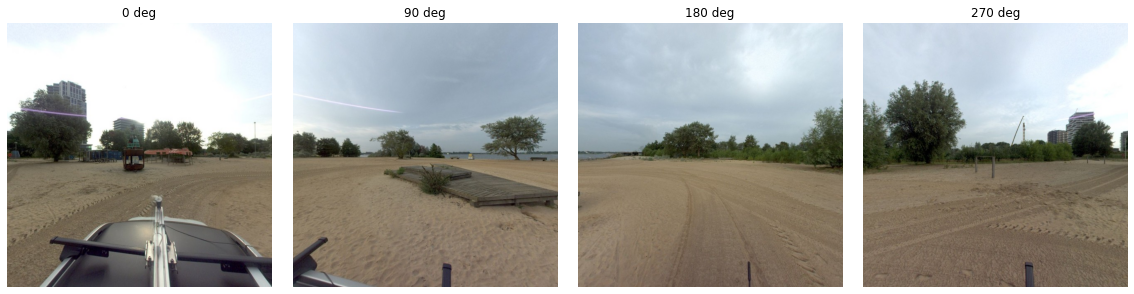

In [4]:
point_index = 0
headings = [0, 90, 180, 270]

with h5py.File(h5_filename, "r") as f:
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    for j, ax in enumerate(axes):
        if not f["images_present"][point_index, j]:
            ax.set_title(f"{headings[j]} deg (missing)")
            ax.axis("off")
            continue
        jpeg_bytes = f["images_jpeg"][point_index, j].tobytes()
        img = Image.open(io.BytesIO(jpeg_bytes)).convert("RGB")
        ax.imshow(img)
        ax.set_title(f"{headings[j]} deg")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

In [5]:
# Find a particular point by its Amsterdam pano_id
with h5py.File(h5_filename, "r") as f:
    pano_ids = [p.decode() for p in f["pano_id"][:]]
    target_pano = pano_ids[0]
    row = pano_ids.index(target_pano)
    rec = {
        "point_id": int(f["point_id"][row]),
        "pano_id": f["pano_id"][row].decode(),
        "latitude": float(f["latitude"][row]),
        "longitude": float(f["longitude"][row]),
        "date": f["date"][row].decode(),
    }
rec

{'point_id': 0,
 'pano_id': 'TMX7316010203-002266_pano_0000_000704',
 'latitude': 52.3383313335052,
 'longitude': 5.1357867600834,
 'date': '2021-08'}

## Verify the acquired sample

The cells below check that the points produced by `panorama_acquisition.py` are geographically and
otherwise sensible. The sample is described by **three views** that the acquisition pipeline keeps in
step:

- **work list** (`panorama_worklist.parquet`) — every location we *planned* to fetch (one row per `pano_id`);
- **manifest** (`panorama_manifest.csv`) — the `pano_id`s whose four crops were *successfully downloaded*;
- **H5 store** (`street_data.h5`) — the points actually *packed into the store* (only points with all
  four crops on disk make it in).

We cross-reference the three to label every point's acquisition status, then map and summarise them.

In [6]:
import os
import pandas as pd

# Paths to the work list / manifest (kept next to the H5 store, under data/raw).
WORKLIST_PATH = os.path.join(raw_dir, "panorama_worklist.parquet")
MANIFEST_PATH = os.path.join(raw_dir, "panorama_manifest.csv")

# --- The three views of the sample -------------------------------------------
worklist = pd.read_parquet(WORKLIST_PATH)          # one row per planned pano_id
manifest = pd.read_csv(MANIFEST_PATH)              # successfully downloaded pano_ids
done_ids = set(manifest["pano_id"])

with h5py.File(h5_filename, "r") as f:
    h5_ids     = {p.decode() for p in f["pano_id"][:]}
    h5_ncrops  = {p.decode(): int(n) for p, n in
                  zip(f["pano_id"][:], f["images_present"][:].sum(1))}

# --- Label every work-list point with its acquisition status -----------------
def _status(pid):
    if pid in h5_ids:
        return "In H5 store (4 crops)"
    if pid in done_ids:
        return "Downloaded, not yet in H5"
    return "Pending download"

points = worklist.copy()
points["status"]  = points["pano_id"].map(_status)
points["n_crops"] = points["pano_id"].map(h5_ncrops).fillna(0).astype(int)
points["year"]    = points["mission_year"].astype(int)

# --- Sanity checks: anything downloaded / stored that is NOT in the worklist? -
# (Can happen legitimately if the worklist was re-thinned after a download run.)
orphan_manifest = done_ids - set(worklist["pano_id"])
orphan_h5       = h5_ids   - set(worklist["pano_id"])

print(f"Work-list points : {len(worklist)}")
print(f"Downloaded       : {len(done_ids)}  ({len(done_ids) / len(worklist):.0%} of work list)")
print(f"In H5 store      : {len(h5_ids)}")
print("\nAcquisition status breakdown:")
print(points["status"].value_counts().to_string())
if orphan_manifest or orphan_h5:
    print(f"\n[!] {len(orphan_manifest)} manifest and {len(orphan_h5)} H5 pano_id(s) are NOT in the "
          "current work list\n    (e.g. the work list was re-thinned after downloading).")
else:
    print("\nAll downloaded / stored points are accounted for in the work list. ✓")

Work-list points : 50162
Downloaded       : 93815  (187% of work list)
In H5 store      : 50048

Acquisition status breakdown:
status
In H5 store (4 crops)    50048
Pending download           114

[!] 43767 manifest and 0 H5 pano_id(s) are NOT in the current work list
    (e.g. the work list was re-thinned after downloading).


### Overview map — all points by acquisition status

Every work-list point on an interactive basemap, coloured by status, so the geography can be eyeballed
(are the points really on Amsterdam streets, do they cover the expected area, are any obviously
misplaced?). Each status is a toggleable layer; **pending** points are drawn larger and in red so
gaps in coverage stand out. Hover a point for its `pano_id`, year and status.

In [7]:
import folium

# colour + marker radius per status (pending = red and larger, so coverage gaps pop out)
STATUS_STYLE = {
    "In H5 store (4 crops)":     ("#2ca02c", 2),   # green
    "Downloaded, not yet in H5": ("#ff7f0e", 3),   # orange
    "Pending download":          ("#d62728", 4),   # red
}

centre = [points["lat"].mean(), points["lon"].mean()]
m = folium.Map(location=centre, zoom_start=15, tiles="CartoDB positron", control_scale=True)

for status, (colour, radius) in STATUS_STYLE.items():
    sub = points[points["status"] == status]
    if sub.empty:
        continue
    fg = folium.FeatureGroup(name=f"{status} ({len(sub)})", show=True)
    for _, r in sub.iterrows():
        folium.CircleMarker(
            location=[r["lat"], r["lon"]], radius=radius,
            color=colour, weight=1, fill=True, fill_color=colour, fill_opacity=0.85,
            tooltip=f"{r['pano_id']}<br>{r['year']} · {r['status']}",
        ).add_to(fg)
    fg.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)

# Fit the view to the points, then drop in a small fixed legend.
m.fit_bounds([[points["lat"].min(), points["lon"].min()],
              [points["lat"].max(), points["lon"].max()]])
legend = ("<div style='position:fixed;bottom:30px;left:30px;z-index:9999;background:white;"
          "padding:8px 12px;border:1px solid #999;border-radius:4px;font-size:12px'>"
          "<b>Acquisition status</b><br>")
for status, (colour, _) in STATUS_STYLE.items():
    n = int((points["status"] == status).sum())
    legend += f"<span style='color:{colour};font-size:16px'>&#9679;</span> {status} ({n})<br>"
legend += "</div>"
m.get_root().html.add_child(folium.Element(legend))
m

### Sample statistics

A quick numeric profile of the sample: when the imagery was captured (`mission_year` / `date`), how
complete each point's crops are, the temporal and geographic spans, and how the points distribute
across Amsterdam **buurten** (the study's spatial unit) — a sanity check on coverage and on how
recent the imagery is.

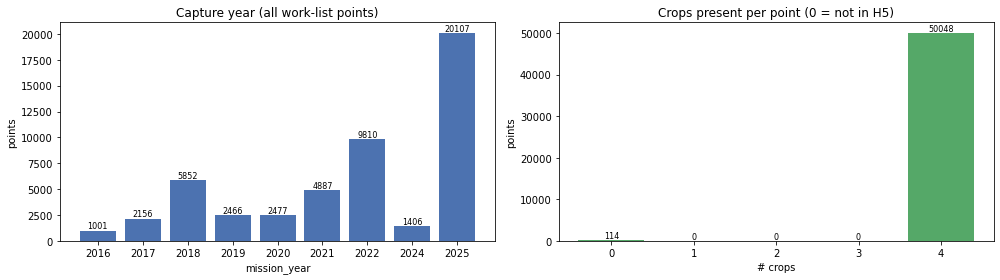

Capture months    : 2016-04 → 2026-01  (86 distinct months, H5 points)
Most-recent year  : 2025  (20107 points, 40%)
Bounding box lon  : 4.7569 → 5.3505
Bounding box lat  : 52.2420 → 52.4258



Buurt coverage    : points fall in 641 of 839 Amsterdam buurten
Points per buurt  : median 66, max 676 (min 1)


In [8]:
with h5py.File(h5_filename, "r") as f:
    dates_h5 = pd.Series([d.decode() for d in f["date"][:]])   # "YYYY-MM", H5 points only

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# (a) capture-year distribution across the whole work list
yc = points["year"].value_counts().sort_index()
axes[0].bar(yc.index.astype(str), yc.values, color="#4c72b0")
axes[0].set_title("Capture year (all work-list points)")
axes[0].set_xlabel("mission_year"); axes[0].set_ylabel("points")
for i, v in enumerate(yc.values):
    axes[0].text(i, v, str(v), ha="center", va="bottom", fontsize=8)

# (b) crops present per point (0 = point not yet in the H5 store)
cc = points["n_crops"].value_counts().reindex(range(5), fill_value=0)
axes[1].bar(cc.index.astype(str), cc.values, color="#55a868")
axes[1].set_title("Crops present per point (0 = not in H5)")
axes[1].set_xlabel("# crops"); axes[1].set_ylabel("points")
for i, v in enumerate(cc.values):
    axes[1].text(i, v, str(v), ha="center", va="bottom", fontsize=8)
plt.tight_layout(); plt.show()

# --- Temporal & spatial spans ------------------------------------------------
latest = int(points["year"].max())
print(f"Capture months    : {dates_h5.min()} → {dates_h5.max()}  "
      f"({dates_h5.nunique()} distinct months, H5 points)")
print(f"Most-recent year  : {latest}  "
      f"({int((points['year'] == latest).sum())} points, {(points['year'] == latest).mean():.0%})")
print(f"Bounding box lon  : {points['lon'].min():.4f} → {points['lon'].max():.4f}")
print(f"Bounding box lat  : {points['lat'].min():.4f} → {points['lat'].max():.4f}")

# --- Buurt coverage (needs the boundary file; skipped gracefully if absent) ---
try:
    import geopandas as gpd
    buurten = gpd.read_file(boundaries_file)
    pts = gpd.GeoDataFrame(
        points, geometry=gpd.points_from_xy(points["lon"], points["lat"]),
        crs=GEOGRAPHIC_CRS).to_crs(buurten.crs)
    joined = gpd.sjoin(pts, buurten[[JOIN_KEY, "geometry"]], how="left", predicate="within")
    per = joined.groupby(JOIN_KEY).size()
    print(f"\nBuurt coverage    : points fall in {joined[JOIN_KEY].nunique()} of "
          f"{len(buurten)} Amsterdam buurten")
    print(f"Points per buurt  : median {per.median():.0f}, max {int(per.max())} (min 1)")
    n_outside = int(joined[JOIN_KEY].isna().sum())
    if n_outside:
        print(f"[!] {n_outside} point(s) fell outside every buurt polygon — check those locations.")
except Exception as e:
    print(f"\n[buurt coverage skipped: {e}]")

### Interactive sample — click a point to see its four views

A random sample of `SAMPLE_N` points drawn from the H5 store, on an interactive basemap. **Click a
marker** to open a popup with that point's four cardinal crops (N / E / S / W) and its metadata, so
the imagery can be spot-checked against its mapped location. The JPEGs are embedded in the popups, so
the map stays self-contained if the notebook is saved or shared. Change `SAMPLE_N` to inspect more
points; the sample is reproducible via `RANDOM_STATE`.

In [9]:
import base64

SAMPLE_N    = 10           # how many points to inspect interactively
RANDOM_STATE = 42          # reproducible sample
HEADING_LABELS = ["N (0°)", "E (90°)", "S (180°)", "W (270°)"]   # H5 slot order


def _img_tag(jpeg_bytes, label, width=210):
    """An <img> (base64-embedded JPEG) with a small caption, for a popup."""
    b64 = base64.b64encode(jpeg_bytes).decode()
    return (f"<div style='display:inline-block;text-align:center;margin:2px'>"
            f"<div style='font-size:11px'>{label}</div>"
            f"<img src='data:image/jpeg;base64,{b64}' width='{width}'></div>")


rng = np.random.default_rng(RANDOM_STATE)
with h5py.File(h5_filename, "r") as f:
    n_h5 = f["point_id"].shape[0]
    idx = np.sort(rng.choice(n_h5, size=min(SAMPLE_N, n_h5), replace=False))

    smap, bounds = folium.Map(tiles="CartoDB positron", control_scale=True), []
    for i in idx:
        lat, lon = float(f["latitude"][i]), float(f["longitude"][i])
        pid, date, year = f["pano_id"][i].decode(), f["date"][i].decode(), int(f["mission_year"][i])
        crops = "".join(
            _img_tag(f["images_jpeg"][i, j].tobytes(), HEADING_LABELS[j])
            if f["images_present"][i, j]
            else f"<div style='display:inline-block;width:210px;margin:2px'>"
                 f"{HEADING_LABELS[j]} (missing)</div>"
            for j in range(4)
        )
        html = (f"<div style='width:460px'><b>point_id {int(f['point_id'][i])}</b> · {pid}<br>"
                f"{date} (year {year}) · {lat:.5f}, {lon:.5f}<div>{crops}</div></div>")
        folium.Marker([lat, lon], popup=folium.Popup(html, max_width=480),
                      tooltip=f"{pid} — click for 4 views").add_to(smap)
        bounds.append([lat, lon])

smap.fit_bounds(bounds, padding=(30, 30))
print(f"Showing {len(idx)} randomly-sampled points — click a marker for its N/E/S/W views.")
smap

Showing 10 randomly-sampled points — click a marker for its N/E/S/W views.
